In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px  # interactive figures
import plotly.graph_objects as go
import seaborn as sns


In [2]:
import pandas as pd

df = pd.read_csv("../data_raw/date_24_art_loreal_20%.csv")

df = df[df["ID_ARTICOL"] == 147807]

df.head()


,DATA,ID_ARTICOL,ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_IESIRE_CU_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,STOC_FINAL,RUPTURA_STOC
12,01-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0
19,02-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,0,0.00,0.0,0.00,0.0,0.0,0.00,278,278,0
30,03-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.00,770.0,574.75,0.0,0.0,72.25,278,267,0
51,04-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,11,647.04,770.0,574.75,0.0,0.0,72.29,267,376,0
64,05-Jan-24,147807,LRP CICAPLAST B5+ BALSAM REPARATOR CALMANT CU ...,10,588.22,700.0,522.50,0.0,0.0,65.72,376,366,0


standard deviation is a way to measure how "spread out" or "different" the values in a group are from the average.

If the standard deviation is small, it means most values are close to the average (not much variation).
If the standard deviation is large, it means the values are spread out and vary a lot from the average.

Conversie coloana data din object in datetime

In [3]:
df['DATA'] = pd.to_datetime(df['DATA'], errors="coerce")

C:\Users\Mara\AppData\Local\Temp\ipykernel_29048\2340964975.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATA'] = pd.to_datetime(df['DATA'], errors="coerce")


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 735 entries, 12 to 9994
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   DATA                  735 non-null    datetime64[ns]
 1   ID_ARTICOL            735 non-null    int64         
 2   ARTICOL               735 non-null    object        
 3   CANTITATE             735 non-null    int64         
 4   VAL_IESIRE_FARA_TVA   735 non-null    float64       
 5   VAL_IESIRE_CU_TVA     735 non-null    float64       
 6   VAL_INTRARE_FARA_TVA  735 non-null    float64       
 7   TOTAL_DISCOUNT        735 non-null    float64       
 8   RATA_DISCOUNT         704 non-null    float64       
 9   ADAOS                 735 non-null    float64       
 10  STOC_INITIAL          735 non-null    int64         
 11  STOC_FINAL            735 non-null    int64         
 12  RUPTURA_STOC          735 non-null    int64         
dtypes: datetime64[ns](1), f

In [5]:
# Sortare logică pentru time series
df = df.sort_values(by=["DATA"]).reset_index(drop=True)

In [6]:
# reguli de calitate
checks = {}

# 1) vânzare > 0 dar valoare = 0 (suspect)
checks["qty_pos_val_zero"] = df[(df["CANTITATE"] > 0) & (df["VAL_IESIRE_CU_TVA"] == 0)]

# 2) valoare > 0 dar cantitate = 0 (suspect)
checks["val_pos_qty_zero"] = df[(df["VAL_IESIRE_CU_TVA"] > 0) & (df["CANTITATE"] == 0)]

# 3) stoc final negativ (dacă există în dataset)
if "STOC_FINAL" in df.columns:
    checks["stoc_final_negativ"] = df[df["STOC_FINAL"] < 0]

# 4) discount > 0 dar rata_discount = 0 (suspect)
if "TOTAL_DISCOUNT" in df.columns and "RATA_DISCOUNT" in df.columns:
    checks["disc_pos_rata_zero"] = df[(df["TOTAL_DISCOUNT"] > 0) & (df["RATA_DISCOUNT"] == 0)]

# 5) 
checks["stockout_start"] = df[(df["STOC_INITIAL"] == 0) & (df["CANTITATE"] == 0)]
checks["no_sales_but_in_stock"] = df[(df["STOC_INITIAL"] > 0) & (df["CANTITATE"] == 0)]

{k: v.shape[0] for k, v in checks.items()}

{'qty_pos_val_zero': 0,
 'val_pos_qty_zero': 0,
 'stoc_final_negativ': 0,
 'disc_pos_rata_zero': 0,
 'stockout_start': 0,
 'no_sales_but_in_stock': 16}

In [7]:
cols = ["CANTITATE", "STOC_INITIAL", "STOC_FINAL", "VAL_IESIRE_FARA_TVA"]

(df[cols] < 0).sum()


CANTITATE              0
STOC_INITIAL           0
STOC_FINAL             0
VAL_IESIRE_FARA_TVA    0
dtype: int64

In [8]:
# df = df.set_index('DATA') 

In [9]:
# df

Pentru evitarea redundanței informaționale, variabilele puternic corelate vor fi filtrate.  ( gen val iesire cu fara tva, total discount - rata discount )

In [10]:
df_feat = df.drop(columns=[ "STOC_FINAL", "RUPTURA_STOC", "VAL_IESIRE_CU_TVA", "RATA_DISCOUNT", "ARTICOL"])

df_feat


,DATA,ID_ARTICOL,CANTITATE,VAL_IESIRE_FARA_TVA,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,ADAOS,STOC_INITIAL
0,2024-01-01,147807,0,0.00,0.00,0.0,0.00,278
1,2024-01-02,147807,0,0.00,0.00,0.0,0.00,278
2,2024-01-03,147807,11,647.00,574.75,0.0,72.25,278
3,2024-01-04,147807,11,647.04,574.75,0.0,72.29,267
4,2024-01-05,147807,10,588.22,522.50,0.0,65.72,376
...,...,...,...,...,...,...,...,...
730,2025-12-31,147807,7,419.44,365.75,0.0,53.69,1429
731,2026-01-01,147807,0,0.00,0.00,0.0,0.00,1422
732,2026-01-02,147807,0,0.00,0.00,0.0,0.00,1422
733,2026-01-03,147807,13,778.96,679.25,0.0,99.71,1422


# XGBoost

### Feature Engineering

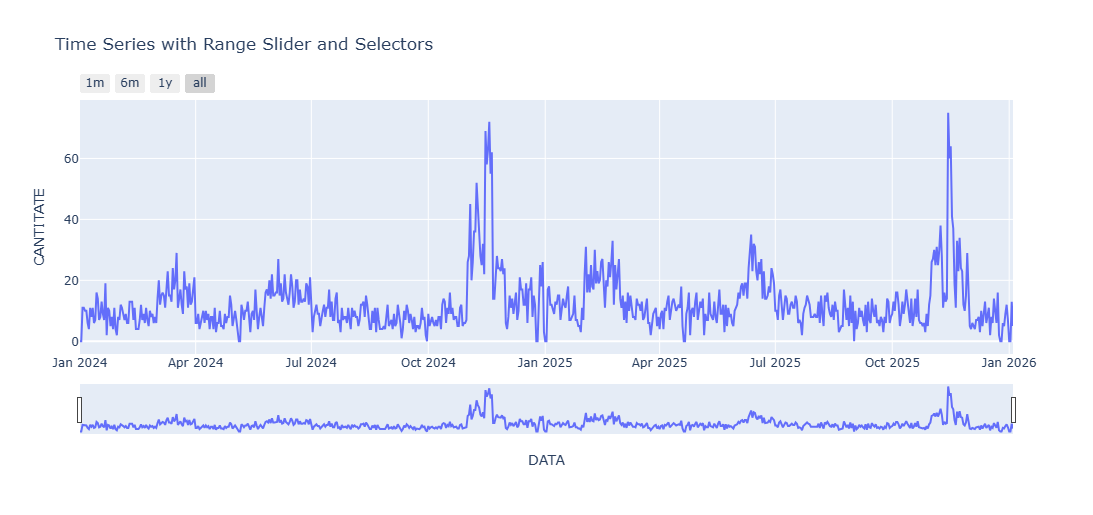

In [11]:
fig = px.line(df, x='DATA', y='CANTITATE', title='Time Series with Range Slider and Selectors')

fig.update_xaxes(
    rangeslider_visible=True,
    rangeselector=dict(
        buttons=list([
            dict(count=1, label="1m", step="month", stepmode="backward"),
            dict(count=6, label="6m", step="month", stepmode="backward"),
            # dict(count=1, label="YTD", step="year", stepmode="todate"),
            dict(count=1, label="1y", step="year", stepmode="backward"),
            dict(step="all")
        ])
    )
)

fig.update_layout(width=1100, height=500)
fig.show()

In [12]:
# Feature engineering for XGBoost (date-based + target history)
df_feat = df.drop(columns=["STOC_FINAL", "RUPTURA_STOC", "VAL_IESIRE_CU_TVA", "ARTICOL"])

# date features
df_feat['DOW'] = df_feat['DATA'].dt.dayofweek
df_feat['month'] = df_feat['DATA'].dt.month
df_feat['ESTE_WEEKEND'] = (df_feat['DOW'] >= 5).astype(int)
df_feat['ZI_DIN_LUNA'] = df_feat['DATA'].dt.day
df_feat['week'] = df_feat['DATA'].dt.isocalendar().week

# lag features (target)
for lag in [1, 7, 14]:
    df_feat[f'lag_{lag}'] = df_feat['CANTITATE'].shift(lag)

# rolling features for target (shifted to avoid leakage)
for window in [7, 14]:
    df_feat[f'roll_mean_{window}'] = df_feat['CANTITATE'].shift(1).rolling(window).mean()
    df_feat[f'roll_std_{window}'] = df_feat['CANTITATE'].shift(1).rolling(window).std()
    df_feat[f'roll_max_{window}'] = df_feat['CANTITATE'].shift(1).rolling(window).max()
    df_feat[f'roll_min_{window}'] = df_feat['CANTITATE'].shift(1).rolling(window).min()

# extra feature: VAL_IESIRE_FARA_TVA (lag + rolling, shifted)
if 'VAL_IESIRE_FARA_TVA' in df_feat.columns:
    for lag in [1, 7, 14]:
        df_feat[f'VAL_IESIRE_FARA_TVA_lag{lag}'] = df_feat['VAL_IESIRE_FARA_TVA'].shift(lag)
    for window in [7, 14]:
        shifted = df_feat['VAL_IESIRE_FARA_TVA'].shift(1)
        df_feat[f'VAL_IESIRE_FARA_TVA_roll_mean_{window}'] = shifted.rolling(window).mean()
        df_feat[f'VAL_IESIRE_FARA_TVA_roll_std_{window}'] = shifted.rolling(window).std()

feature_cols = [
    'DOW', 'month', 'ESTE_WEEKEND', 'ZI_DIN_LUNA', 'week',
    'lag_1', 'lag_7', 'lag_14',
    'roll_mean_7', 'roll_std_7', 'roll_max_7', 'roll_min_7',
    'roll_mean_14', 'roll_std_14', 'roll_max_14', 'roll_min_14'
]
if 'VAL_IESIRE_FARA_TVA' in df_feat.columns:
    feature_cols += [
        'VAL_IESIRE_FARA_TVA_lag1', 'VAL_IESIRE_FARA_TVA_lag7', 'VAL_IESIRE_FARA_TVA_lag14',
        'VAL_IESIRE_FARA_TVA_roll_mean_7', 'VAL_IESIRE_FARA_TVA_roll_std_7',
        'VAL_IESIRE_FARA_TVA_roll_mean_14', 'VAL_IESIRE_FARA_TVA_roll_std_14'
    ]


# drop raw VAL_IESIRE_FARA_TVA to avoid same-day leakage
df_feat = df_feat.drop(columns=['VAL_IESIRE_FARA_TVA'])
# drop rows with NaNs from lag/rolling
df_feat = df_feat.dropna(subset=feature_cols + ['CANTITATE']).copy()


In [13]:
df_feat

,DATA,ID_ARTICOL,CANTITATE,VAL_INTRARE_FARA_TVA,TOTAL_DISCOUNT,RATA_DISCOUNT,ADAOS,STOC_INITIAL,DOW,month,...,roll_std_14,roll_max_14,roll_min_14,VAL_IESIRE_FARA_TVA_lag1,VAL_IESIRE_FARA_TVA_lag7,VAL_IESIRE_FARA_TVA_lag14,VAL_IESIRE_FARA_TVA_roll_mean_7,VAL_IESIRE_FARA_TVA_roll_std_7,VAL_IESIRE_FARA_TVA_roll_mean_14,VAL_IESIRE_FARA_TVA_roll_std_14
14,2024-01-15,147807,14,731.50,0.0,0.0,91.97,287,0,1,...,4.480115,16.0,0.0,941.18,235.28,0.00,529.400000,235.302500,466.370000,263.532911
15,2024-01-16,147807,7,365.75,0.0,0.0,46.05,273,1,1,...,4.122439,16.0,0.0,823.47,647.04,0.00,613.427143,217.083035,525.189286,242.491595
16,2024-01-17,147807,8,418.00,0.0,0.0,52.58,266,2,1,...,3.298351,16.0,4.0,411.80,470.57,647.00,579.821429,228.899009,554.603571,194.016018
17,2024-01-18,147807,13,679.25,0.0,0.0,85.45,258,3,1,...,3.285834,16.0,4.0,470.58,647.07,647.04,579.822857,228.898213,542.002143,193.281085
18,2024-01-19,147807,9,470.25,0.0,0.0,59.15,245,4,1,...,3.410552,16.0,4.0,764.70,352.93,588.22,596.627143,238.763148,550.406429,200.618476
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730,2025-12-31,147807,7,365.75,0.0,0.0,53.69,1429,2,12,...,4.990100,16.0,0.0,719.02,119.84,119.84,291.032857,273.331503,410.873571,299.001358
731,2026-01-01,147807,0,0.00,0.0,0.0,0.00,1422,3,1,...,4.790673,16.0,0.0,419.44,0.00,479.35,333.832857,265.398815,432.273571,287.051987
732,2026-01-02,147807,0,0.00,0.0,0.0,0.00,1422,4,1,...,5.153149,16.0,0.0,0.00,0.00,359.52,333.832857,265.398815,398.034286,308.771338
733,2026-01-03,147807,13,679.25,0.0,0.0,99.71,1422,5,1,...,5.451585,16.0,0.0,0.00,359.52,838.88,333.832857,265.398815,372.354286,326.653437


In [14]:
split_idx = len(df_feat) - 14
train_df = df_feat.iloc[:split_idx].copy()
test_df  = df_feat.iloc[split_idx:].copy()

# opțional: scoți din TRAIN zilele de stock-out (corect pentru cerere)
if "STOC_INITIAL" in train_df.columns:
    train_df = train_df[~((train_df["STOC_INITIAL"] == 0) & (train_df["CANTITATE"] == 0))].copy()


In [15]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

target = "CANTITATE"
drop_cols = ["DATA", target]
X_cols = [c for c in train_df.columns if c not in drop_cols]

xgb = XGBRegressor(
    n_estimators=600, # # number of boosting rounds (trees)
    max_depth=6, # maximum depth per tree
    learning_rate=0.03,
    subsample=0.9, # fraction of rows per tree
    colsample_bytree=0.9, # fraction of features per tree
    reg_lambda=1.0,
    random_state=42 # reproducibility
)



xgb.fit(train_df[X_cols], train_df[target])
pred_xgb = xgb.predict(test_df[X_cols])

y_true = test_df[target].values
mae = mean_absolute_error(y_true, pred_xgb)
rmse = np.sqrt(mean_squared_error(y_true, pred_xgb))
r2 = r2_score(y_true, pred_xgb)

mae, rmse, r2


(0.030510034412145615, np.float64(0.044775587287396064), 0.9999212622642517)

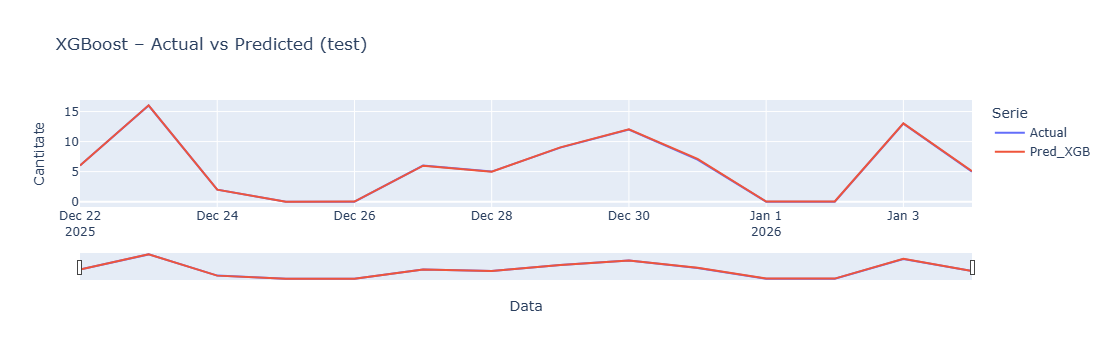

In [16]:
import plotly.express as px

df_plot = pd.DataFrame({
    "DATA": test_df["DATA"].values,
    "Actual": y_true,
    "Pred_XGB": pred_xgb
})

df_long = df_plot.melt("DATA", var_name="Serie", value_name="Cantitate")
fig = px.line(df_long, x="DATA", y="Cantitate", color="Serie",
              title="XGBoost – Actual vs Predicted (test)")
fig.update_layout(hovermode="x unified", xaxis_title="Data", yaxis_title="Cantitate")
fig.update_xaxes(rangeslider_visible=True)
fig.show()
